# Test-Time Scaling on FinQA: Initial Analysis

Loads experiment JSON files from `results/`, plots accuracy vs. number of samples (N) and vs. total generated tokens, and surfaces individual trajectories for failure analysis.

This notebook only reads result files — it does not run any model or execute any generated code itself.

In [1]:
import json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt

RESULTS_DIR = Path("../results")

In [2]:
def load_experiments(results_dir: Path) -> list[dict]:
    experiments = []
    for path in sorted(results_dir.glob("*.json")):
        with open(path) as f:
            experiments.append(json.load(f))
    return experiments


experiments = load_experiments(RESULTS_DIR)
print(f"Loaded {len(experiments)} experiment files.")

Loaded 3 experiment files.


In [3]:
summary = pd.DataFrame([
    {
        "experiment_id": e["experiment_id"],
        "strategy": e["strategy"],
        "num_samples": e["num_samples"],
        "model": e["model"],
        "accuracy": e["metrics"]["accuracy"],
        "average_tokens": e["metrics"]["average_tokens"],
        "average_latency": e["metrics"]["average_latency"],
        "num_examples": e["metrics"]["num_examples"],
    }
    for e in experiments
])
summary.sort_values("num_samples")

,experiment_id,strategy,num_samples,model,accuracy,average_tokens,average_latency,num_examples
0,greedy_n1_20260917_131136_e9531c,greedy,1,Qwen/Qwen2.5-0.5B-Instruct,0.00,968.50,6.338336,2
1,sampling_n4_20260918_205310_e7d232,sampling,4,Qwen/Qwen2.5-3B-Instruct,0.25,5066.45,77.374005,20
2,sampling_n8_20260918_215700_816ee2,sampling,8,Qwen/Qwen2.5-3B-Instruct,0.35,10036.75,146.055314,20


## Accuracy vs. number of samples (N)

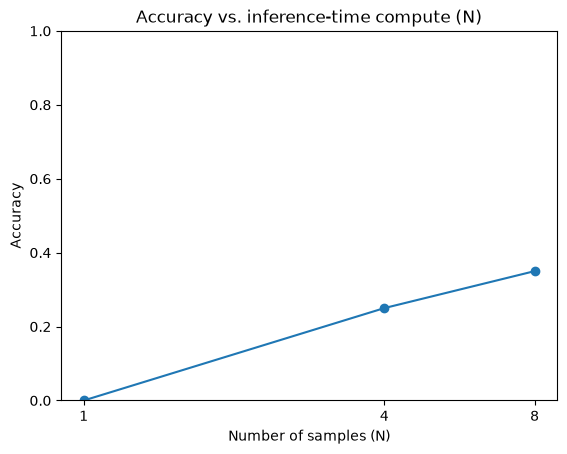

In [4]:
by_n = summary.sort_values("num_samples")

fig, ax = plt.subplots()
ax.plot(by_n["num_samples"], by_n["accuracy"], marker="o")
ax.set_xscale("log", base=2)
ax.set_xticks(by_n["num_samples"])
ax.set_xticklabels(by_n["num_samples"])
ax.set_xlabel("Number of samples (N)")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. inference-time compute (N)")
ax.set_ylim(0, 1)
plt.show()

## Accuracy vs. total generated tokens

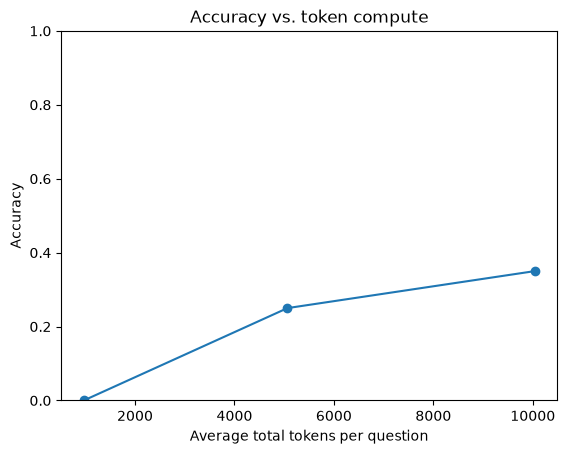

In [5]:
by_tokens = summary.sort_values("average_tokens")

fig, ax = plt.subplots()
ax.plot(by_tokens["average_tokens"], by_tokens["accuracy"], marker="o")
ax.set_xlabel("Average total tokens per question")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs. token compute")
ax.set_ylim(0, 1)
plt.show()

## Per-question breakdown

For each question, how many of the N samples were correct, wrong, or failed outright (no code extracted, or the code errored / timed out).


In [ ]:
def examples_df(experiment: dict) -> pd.DataFrame:
    rows = []
    for ex in experiment["examples"]:
        verifications = [t.get("verification") for t in ex["trajectories"]]
        ran = [v for v in verifications if v and v.get("success")]
        rows.append({
            "question_id": ex["question_id"],
            "correct": ex["correct"],  # final (majority-vote) answer is correct
            "final_answer": ex["final_answer"],
            "samples_correct": sum(1 for v in ran if v["correct"]),
            "samples_wrong": sum(1 for v in ran if not v["correct"]),
            "samples_failed": len(verifications) - len(ran),
        })
    return pd.DataFrame(rows)


# Point this at the N=1 and N=8 (or highest-N) experiment files to compare.
n1_experiments = [e for e in experiments if e["num_samples"] == 1]
n8_experiments = [e for e in experiments if e["num_samples"] >= 8]

n1_df = examples_df(n1_experiments[0]) if n1_experiments else None
n8_df = examples_df(n8_experiments[0]) if n8_experiments else None
# n1_df, n8_df

n8_df

ZeroDivisionError: division by zero

### Cases where N=1 fails but higher N succeeds

In [15]:
if n1_df is not None and n8_df is not None:
    merged = n1_df.merge(n8_df, on="question_id", suffixes=("_n1", "_nhigh"))
    flips_to_correct = merged[(~merged["correct_n1"]) & (merged["correct_nhigh"])]
    print(f"{len(flips_to_correct)} / {len(merged)} questions flipped from incorrect (N=1) to correct (higher N)")
    flips_to_correct[["question_id", "final_answer_n1", "final_answer_nhigh"]]

1 / 2 questions flipped from incorrect (N=1) to correct (higher N)


### Questions the higher-N run got wrong


In [12]:
if n8_df is not None:
    display(n8_df[~n8_df["correct"]][["question_id", "samples_correct", "samples_wrong", "samples_failed"]])


,question_id,samples_correct,samples_wrong,samples_failed
1,C/2017/page_328.pdf-1,0,7,1
3,ETR/2011/page_341.pdf-3,0,4,4
4,ETR/2004/page_213.pdf-2,0,8,0
6,JPM/2008/page_85.pdf-3,2,5,1
7,PNC/2013/page_207.pdf-1,0,7,1
11,PKG/2009/page_65.pdf-4,0,8,0
12,LMT/2013/page_74.pdf-4,0,7,1
13,STT/2011/page_83.pdf-1,0,7,1
15,AOS/2004/page_11.pdf-2,0,7,1
16,C/2010/page_223.pdf-3,0,8,0


### Execution catching a bad solution (model stated an answer, but its code errored or disagreed)

In [13]:
if n8_experiments:
    for ex in n8_experiments[0]["examples"][:20]:
        for t in ex["trajectories"]:
            v = t.get("verification")
            if v and not v["success"] and t.get("stated_answer"):
                print(ex["question_id"], "stated:", t["stated_answer"], "| execution_error:", v["execution_error"])

C/2017/page_328.pdf-1 stated: 83.45 | execution_error: rejected by safety check: import statements are not allowed
ETR/2011/page_341.pdf-3 stated: 18.6 | execution_error: code did not assign a variable named `answer`
ETR/2011/page_341.pdf-3 stated: 18.6 | execution_error: code did not assign a variable named `answer`
ETR/2011/page_341.pdf-3 stated: 18.6 | execution_error: code did not assign a variable named `answer`
ETR/2011/page_341.pdf-3 stated: 18.6 | execution_error: code did not assign a variable named `answer`
JPM/2008/page_85.pdf-3 stated: 85.05 | execution_error: code did not assign a variable named `answer`
PNC/2013/page_207.pdf-1 stated: 83.21 | execution_error: code did not assign a variable named `answer`
LMT/2013/page_74.pdf-4 stated: -1.9 | execution_error: rejected by safety check: SyntaxError: invalid decimal literal (<unknown>, line 2)
STT/2011/page_83.pdf-1 stated: -76 | execution_error: code did not assign a variable named `answer`
MRO/2007/page_149.pdf-2 stated: 33

### % of examples where additional samples changed the outcome

In [14]:
if n1_df is not None and n8_df is not None:
    merged = n1_df.merge(n8_df, on="question_id", suffixes=("_n1", "_nhigh"))
    changed = merged["correct_n1"] != merged["correct_nhigh"]
    print(f"{changed.mean() * 100:.1f}% of examples changed outcome between N=1 and higher N")

50.0% of examples changed outcome between N=1 and higher N
